<a href="https://colab.research.google.com/github/dhanushbt/AI_ML_BASICS/blob/test_branch/image_compression_using_lowrank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
from PIL import Image
import matplotlib.pyplot as plt

In [9]:
url='https://channeli.in/api/django_filemanager/media_files/12069/'
myImg=io.imread(url)

In [13]:
gray_img=cv.cvtColor(myImg,cv.COLOR_BGR2GRAY)
img_mat=np.array(list(gray_img),float)

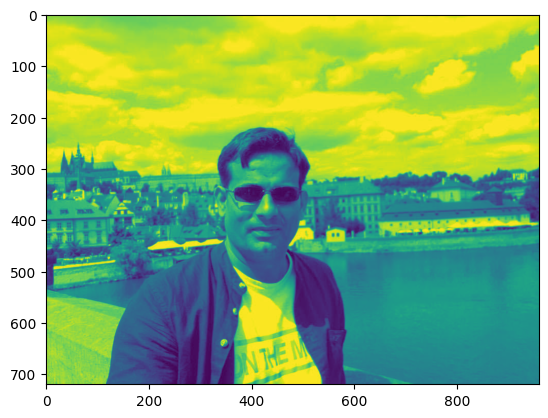

In [17]:
img_mat.shape
plt.imshow(img_mat)

In [18]:
img_scaled=(img_mat-img_mat.mean())/(img_mat.std())
img_scaled

array([[ 0.54372575,  0.54372575,  0.54372575, ...,  1.0610143 ,
         1.0610143 ,  1.0610143 ],
       [ 0.54372575,  0.54372575,  0.55770652, ...,  1.0610143 ,
         1.0610143 ,  1.0610143 ],
       [ 0.55770652,  0.55770652,  0.55770652, ...,  1.0610143 ,
         1.0610143 ,  1.0610143 ],
       ...,
       [ 0.45984111,  0.52974497,  0.58566806, ..., -0.6726014 ,
        -0.6726014 , -0.6726014 ],
       [ 0.43187957,  0.50178343,  0.57168729, ..., -0.65862063,
        -0.65862063, -0.6726014 ],
       [ 0.3200334 ,  0.40391803,  0.47382189, ..., -0.64463985,
        -0.65862063, -0.6726014 ]])

In [19]:
u,s,vt=np.linalg.svd(img_scaled)

In [22]:
var_explained=np.round(s**2/np.sum(s**2),decimals=3)


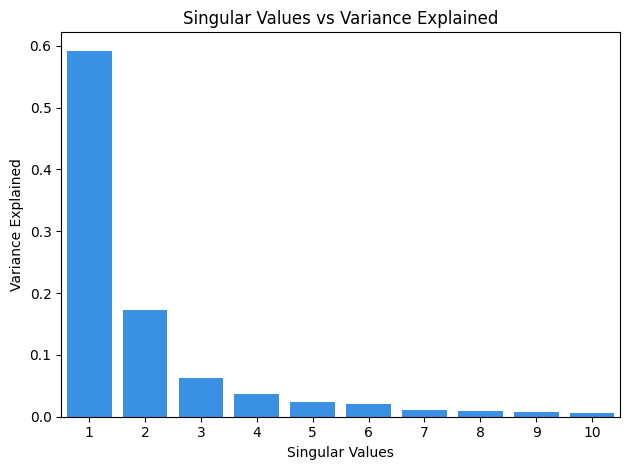

In [25]:
import seaborn as sns
sns.barplot(x=list(range(1,11)),y=var_explained[:10],color="dodgerblue")
plt.xlabel("Singular Values")
plt.ylabel("Variance Explained")
plt.title("Singular Values vs Variance Explained")

plt.show()

In [41]:
num_compression=200
recon_img=np.array(u[:,:num_compression]).dot(np.diag(s[:num_compression]).dot(vt[:num_compression,:]))

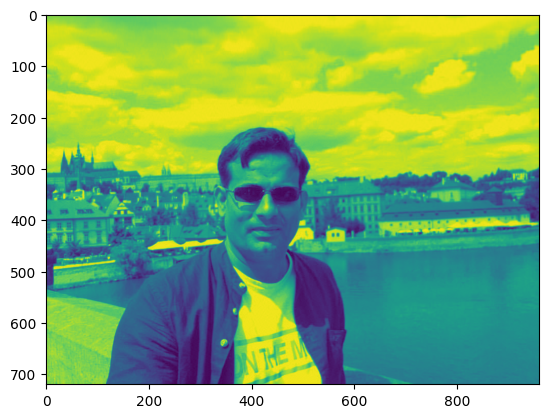

In [42]:
plt.imshow(recon_img)